In [1]:
from folde.types import FolDEModelConfig, ModelDiff
from folde.campaign import simulate_campaigns
from folde.util import apply_diff_list_to_config
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

base_config = FolDEModelConfig(
    name="FolDE",
    # Required parameters
    naturalness_model_id="600m",  # ESM-2 650M model
    embedding_model_id="300m_extras",  # Same model for embeddings
    zero_shot_model_name="NaturalnessZeroShotModel",
    zero_shot_model_params={},
    # Few-shot model configuration (used after first round)
    few_shot_model_name="TorchMLPFewShotModel",
    few_shot_model_params={
        "pretrain": True,
        "pretrain_epochs": 50,

        "ensemble_size": 5,
        "decision_mode": "ucb",

        "embedding_dim": 960,
        "hidden_dims": [100, 50],
        "dropout": 0.2,
        "learning_rate": 0.001,
        "weight_decay": 1e-5,
        "train_epochs": 400,
        "train_patience": None,
        "val_frequency": 10,
    },
)

config_list = apply_diff_list_to_config(
    base_config,
    [
        ModelDiff(
            name="pairHoldout-liar",
            diffs={
                # "few_shot_model_params.importance_sampling_reweighting_strat": 'min',
                # "few_shot_model_params.importance_sampling_temperature": 10.0,
                "few_shot_model_params.do_validation_with_pair_fraction": 0.2,
                "few_shot_model_params.train_patience": 30,
                "few_shot_model_params.decision_mode": "constantliar",
                "few_shot_model_params.lie_noise_stddev_multiplier": 2.0,
            }
        ),
        # ModelDiff(
        #     name="reweight_min",
        #     diffs={
        #         "few_shot_model_params.importance_sampling_reweighting_strat": 'min',
        #         "few_shot_model_params.importance_sampling_temperature": 10.0
        #     }
        # ),
        # ModelDiff(
        #     name="reweight_min_holdout",
        #     diffs={
        #         "few_shot_model_params.importance_sampling_reweighting_strat": 'min',
        #         "few_shot_model_params.importance_sampling_temperature": 10.0,
        #         "few_shot_model_params.do_holdout_validation": True,
        #     }
        # ),
        # ModelDiff(
        #     name="reweight_max",
        #     diffs={
        #         "few_shot_model_params.importance_sampling_reweighting_strat": 'max',
        #         "few_shot_model_params.importance_sampling_temperature": 10.0
        #     }
        # ),
        # ModelDiff(
        #     name="cheat_val_loss",
        #     diffs={
        #         "few_shot_model_params.train_patience": 10,
        #         "few_shot_model_params.cheating_is_ok_i_accept_the_consequences": True
        #     }
        # ),
        # ModelDiff(
        #     name="importance_sampling_cheat_val_loss",
        #     diffs={
        #         "few_shot_model_params.do_importance_sampling": True,
        #         # When we normalize the loss... many loss magnitudes go down... this compensates.
        #         "few_shot_model_params.learning_rate": 0.001 * 3,
        #         "few_shot_model_params.train_patience": 10,
        #         "few_shot_model_params.cheating_is_ok_i_accept_the_consequences": True
        #     }
        # ),
    ]
)
results = simulate_campaigns(
    name='tmp_exp',
    dms_ids=['ANCSZ_Hobbs_2022'],
    round_size=16,
    number_of_simulations=3,
    config_list=config_list,
    activity_column="DMS_score",
    max_rounds=3,
    random_seed=42,
)

2025-05-24 23:57:04,896 - folde.campaign - INFO - Running simulations for configuration 1/2
2025-05-24 23:57:04,897 - folde.campaign - INFO - Config: name='FolDE-base' naturalness_model_id='600m' embedding_model_id='300m_extras' embedding_column=None zero_shot_model_name='NaturalnessZeroShotModel' zero_shot_model_params={} few_shot_model_name='TorchMLPFewShotModel' few_shot_naturalness_column=None few_shot_model_params={'pretrain': True, 'pretrain_epochs': 50, 'ensemble_size': 5, 'decision_mode': 'ucb', 'embedding_dim': 960, 'hidden_dims': [100, 50], 'dropout': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'train_epochs': 400, 'train_patience': None, 'val_frequency': 10}
2025-05-24 23:57:04,940 - folde.data - INFO - Loaded activity data for ANCSZ_Hobbs_2022 with 4670 rows
2025-05-24 23:57:09,528 - folde.data - INFO - Loaded embeddings for ANCSZ_Hobbs_2022 with 11914 rows
2025-05-24 23:57:09,562 - folde.data - INFO - Loaded naturalness scores for ANCSZ_Hobbs_2022 with 20691 rows
2

Selecting K378F (original rank 1), score: 2.9842692375183106 = 2.9842692375183106
Selecting Q571K (original rank 2), score: 2.691033469069366 = 2.691033469069366
Selecting R359D (original rank 3), score: 2.5147691879210288 = 2.5147691879210288
Selecting N400L (original rank 6), score: 2.34495643135454 = 2.34495643135454
Selecting R359L (original rank 4), score: 2.245686648639042 = 2.245686648639042
Selecting H539A (original rank 5), score: 2.1505831394011112 = 2.1505831394011112
Selecting E360L (original rank 38), score: 2.1984276065674666 = 2.1984276065674666
Selecting Q361L (original rank 8), score: 2.113739424481606 = 2.113739424481606


2025-05-24 23:59:17,364 - app.helpers.preference_ranking - INFO - Early stopping at epoch 150
2025-05-24 23:59:17,368 - root - INFO - Finetune improvement: train loss (2.8502 -> 0.0590) val loss (1.5850 -> 0.1071)


Selecting Y531F (original rank 10), score: 2.0697233403070703 = 2.0697233403070703
Selecting E595A (original rank 34), score: 1.8378182835671983 = 1.8378182835671983
Selecting R359I (original rank 28), score: 1.8716943798571564 = 1.8716943798571564
Selecting Q497W (original rank 22), score: 1.781050112700988 = 1.781050112700988
Selecting Q361V (original rank 77), score: 1.7314354341951461 = 1.7314354341951461
Selecting Q562K (original rank 18), score: 1.7279853257854467 = 1.7279853257854467
Selecting V460F (original rank 16), score: 1.6531438876997797 = 1.6531438876997797
Selecting S398F (original rank 142), score: 1.6901619440278672 = 1.6901619440278672


2025-05-24 23:59:17,950 - root - INFO - Pretraining model with naturalness data with 2335 single mutants.
2025-05-24 23:59:18,476 - app.helpers.preference_ranking - INFO - Early stopping at epoch 160
2025-05-24 23:59:18,479 - root - INFO - Finetune improvement: train loss (2.0273 -> 0.0600) val loss (1.3883 -> 0.1838)
2025-05-24 23:59:19,109 - root - INFO - Pretrain loss: train 0.6408 -> 0.1367, val 0.6929 -> 0.3599 after 110 epochs
2025-05-24 23:59:19,669 - app.helpers.preference_ranking - INFO - Early stopping at epoch 190
2025-05-24 23:59:19,672 - root - INFO - Finetune improvement: train loss (2.7241 -> 0.0549) val loss (2.0749 -> 0.0824)
2025-05-24 23:59:19,990 - app.helpers.preference_ranking - INFO - Early stopping at epoch 50
2025-05-24 23:59:19,997 - root - INFO - Finetune improvement: train loss (3.2966 -> 0.0841) val loss (1.9544 -> 0.7909)
2025-05-24 23:59:20,472 - app.helpers.preference_ranking - INFO - Early stopping at epoch 210
2025-05-24 23:59:20,477 - root - INFO - Fi

...

Selecting L616R (original rank 1), score: 1.9669357776641845 = 1.9669357776641845
Selecting F482A (original rank 10), score: 1.5380253164660045 = 1.5380253164660045
Selecting L616A (original rank 2), score: 1.5160569855609234 = 1.5160569855609234
Selecting E592R (original rank 13), score: 1.4521978365630324 = 1.4521978365630324
Selecting F482V (original rank 5), score: 1.3574858449656653 = 1.3574858449656653
Selecting E578A (original rank 59), score: 1.3592788336705706 = 1.3592788336705706
Selecting Q571Y (original rank 73), score: 1.2463914684108506 = 1.2463914684108506
Selecting F482E (original rank 7), score: 1.275130871087042 = 1.275130871087042
Selecting Q497A (original rank 39), score: 1.2585696636435746 = 1.2585696636435746
Selecting E591R (original rank 70), score: 1.2397437408667698 = 1.2397437408667698
Selecting E592F (original rank 96), score: 1.2075143785441822 = 1.2075143785441822


2025-05-24 23:59:42,279 - root - INFO - Pretrain loss: train 0.6408 -> 0.1367, val 0.6929 -> 0.3599 after 110 epochs


Selecting E592K (original rank 16), score: 1.2063439928820126 = 1.2063439928820126
Selecting E591K (original rank 49), score: 1.1720655849054782 = 1.1720655849054782
Selecting E431L (original rank 246), score: 1.1967407968750217 = 1.1967407968750217
Selecting M554D (original rank 12), score: 1.2242876362295712 = 1.2242876362295712
Selecting E366N (original rank 80), score: 1.176977428167229 = 1.176977428167229


2025-05-24 23:59:43,138 - app.helpers.preference_ranking - INFO - Early stopping at epoch 150
2025-05-24 23:59:43,140 - root - INFO - Finetune improvement: train loss (1.3833 -> 0.0833) val loss (1.0288 -> 0.1390)
2025-05-24 23:59:43,346 - app.helpers.preference_ranking - INFO - Early stopping at epoch 40
2025-05-24 23:59:43,349 - root - INFO - Finetune improvement: train loss (1.1817 -> 0.1008) val loss (0.7902 -> 0.6435)
2025-05-24 23:59:44,002 - app.helpers.preference_ranking - INFO - Early stopping at epoch 150
2025-05-24 23:59:44,005 - root - INFO - Finetune improvement: train loss (1.0071 -> 0.0688) val loss (0.8927 -> 0.1799)
2025-05-24 23:59:44,227 - app.helpers.preference_ranking - INFO - Early stopping at epoch 40
2025-05-24 23:59:44,230 - root - INFO - Finetune improvement: train loss (0.8267 -> 0.1454) val loss (1.0238 -> 1.0021)
2025-05-24 23:59:44,816 - app.helpers.preference_ranking - INFO - Early stopping at epoch 140
2025-05-24 23:59:44,818 - root - INFO - Finetune imp

Selecting L616H (original rank 1), score: 1.6268948078155518 = 1.6268948078155518
Selecting M363V (original rank 11), score: 1.5509397366301256 = 1.5509397366301256
Selecting N400V (original rank 5), score: 1.400173153069413 = 1.400173153069413
Selecting Y622K (original rank 4), score: 1.2957463976385748 = 1.2957463976385748
Selecting K387D (original rank 31), score: 1.3391288531029535 = 1.3391288531029535
Selecting D419V (original rank 20), score: 1.286496478804434 = 1.286496478804434
Selecting V612D (original rank 10), score: 1.282601327747315 = 1.282601327747315
Selecting I427Y (original rank 48), score: 1.2729296762041888 = 1.2729296762041888
Selecting S434P (original rank 24), score: 1.281448377109512 = 1.281448377109512
Selecting D620R (original rank 81), score: 1.2145876286379866 = 1.2145876286379866
Selecting F576A (original rank 35), score: 1.1765507313555512 = 1.1765507313555512
Selecting Q497A (original rank 19), score: 1.1772754983649434 = 1.1772754983649434
Selecting E581Y

In [2]:
from folde.util import convert_compaign_result_collection_to_df
mutant_df, round_df = convert_compaign_result_collection_to_df(results)

<Axes: xlabel='old_held_out_1pct_recall', ylabel='held_out_1pct_recall'>

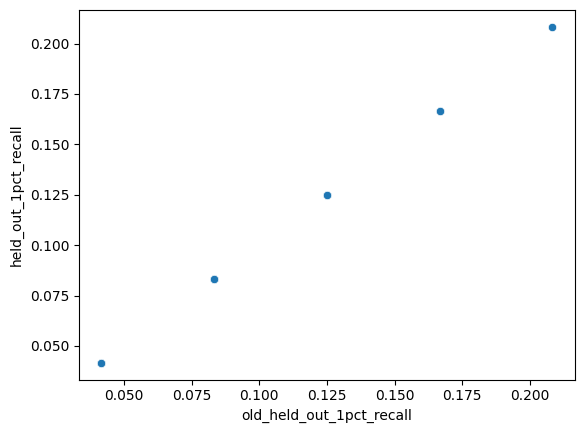

In [3]:
import seaborn as sns
sns.scatterplot(
    data=round_df,
    x='old_held_out_1pct_recall',
    y='held_out_1pct_recall',
)

In [4]:
from folde.util import get_training_loss_df
train_df = get_training_loss_df(results, round_idx=1)
train_df['epoch'] = train_df['log_step'] * 10
train_df.config_name.unique()

array(['FolDE-base', 'FolDE-pairHoldout-liar'], dtype=object)

In [5]:
train_df.groupby(['loss_type', 'config_name', 'sim_idx', 'model_idx']).last()

log_step  \
loss_type            config_name            sim_idx model_idx             
finetune_recall_1pct FolDE-base             0       0                40   
                                                    1                40   
                                                    2                40   
                                                    3                40   
                                                    4                40   
...                                                                 ...   
pretrain_val         FolDE-pairHoldout-liar 2       0                10   
                                                    1                10   
                                                    2                10   
                                                    3                 8   
                                                    4                10   

                                                                   loss  \
loss_type            config_name            sim_idx model_idx             
finetune_recall_1pct FolDE-base             0       0          0.125000   
                                                    1          0.000000   
                                                    2          0.000000   
                                                    3          0.000000   
                                                    4          0.000000   
...                                                                 ...   
pretrain_val         FolDE-pairHoldout-liar 2       0          0.360620   
                                                    1          0.333539   
                                                    2          0.323780   
                                                    3          0.371355   
                                                    4          0.410416   

                                                                         dms_id  \
loss_type            config_name            sim_idx model_idx                     
finetune_recall_1pct FolDE-base             0       0          ANCSZ_Hobbs_2022   
                                                    1          ANCSZ_Hobbs_2022   
                                                    2          ANCSZ_Hobbs_2022   
                                                    3          ANCSZ_Hobbs_2022   
                                                    4          ANCSZ_Hobbs_2022   
...                                                                         ...   
pretrain_val         FolDE-pairHoldout-liar 2       0          ANCSZ_Hobbs_2022   
                                                    1          ANCSZ_Hobbs_2022   
                                                    2          ANCSZ_Hobbs_2022   
                                                    3          ANCSZ_Hobbs_2022   
                                                    4          ANCSZ_Hobbs_2022   

                                                               epoch  
loss_type            config_name            sim_idx model_idx         
finetune_recall_1pct FolDE-base             0       0            400  
                                                    1            400  
                                                    2            400  
                                                    3            400  
                                                    4            400  
...                                                              ...  
pretrain_val         FolDE-pairHoldout-liar 2       0            100  
                                                    1            100  
                                                    2            100  
                                                    3             80  
                                                    4            100  

[150 rows x 4 columns]

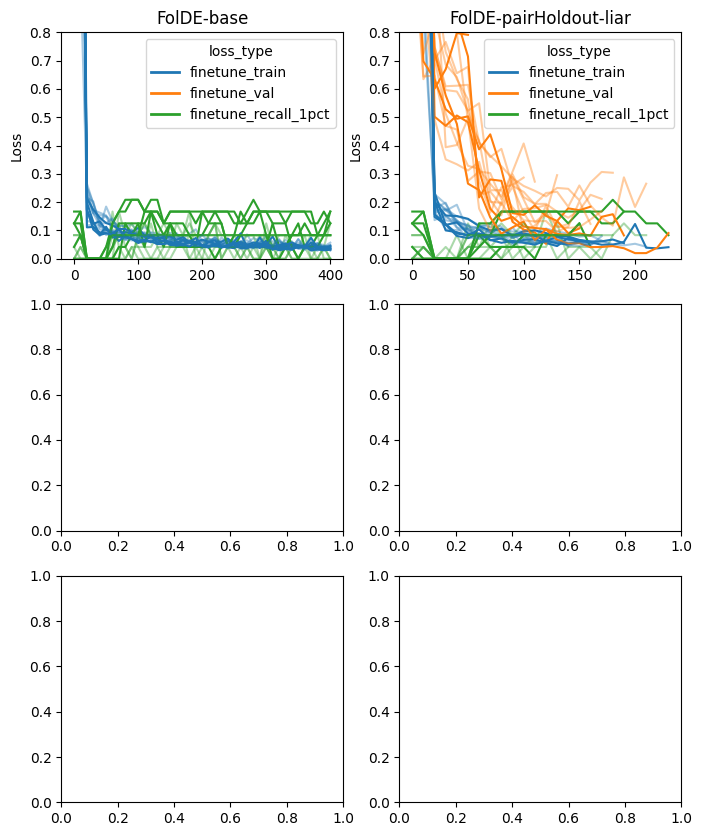

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(8, 10))

for config_name, ax in zip(train_df.config_name.unique(), axs.flatten()):
    plot_df = train_df[
        # (train_df.config_name == 'FolDE_holdout')
        # (train_df.config_name == 'FolDE_reweight_min_holdout')
        (train_df.config_name == config_name)
        # (train_df.config_name == 'FolDE_reweight_max')
        # (train_df.config_name == 'FolDE_base')
        & (train_df.loss_type.str.startswith('finetune'))
    ]

    # Get unique loss_types and assign a color to each
    loss_types = plot_df['loss_type'].unique()
    color_map = {lt: color for lt, color in zip(loss_types, plt.cm.tab10.colors)}
    sim_idx_to_alpha_map = {1: 1.0}


    # Group by sim_idx and model_idx, but color by loss_type
    for (sim_idx, model_idx, loss_type), group in plot_df.groupby(['sim_idx', 'model_idx', 'loss_type']):
        # loss_type = group['loss_type'].iloc[0]
        color = color_map[loss_type]
        alpha = sim_idx_to_alpha_map.get(sim_idx, 0.4)
        ax.plot(group['epoch'], group['loss'], color=color, alpha=alpha)  # alpha for visibility

    # Optionally, add a legend for loss_type
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=color_map[lt], lw=2, label=lt) for lt in loss_types]
    ax.legend(handles=legend_elements, title='loss_type')

    dms_name = '_'.join(plot_df['dms_id'].unique())
    config_name = '_'.join(plot_df['config_name'].unique())
    ax.set_title(f'{config_name}')

    ax.set_xlabel('')
    ax.set_ylabel('Loss')
    ax.set_ylim(0, 0.8)

In [36]:
from folde.util import convert_compaign_result_collection_to_df

mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df.head()

,dms_id,config_name,sim_num,variant_pool_size,best_activity_this_round,best_percentile_this_round,best_activity_so_far,normalized_best_activity_so_far,best_percentile_so_far,round_num,model_spearman,misc,held_out_activity_spearman,held_out_1pct_recall,held_out_1pct_auc,held_out_10pct_recall,held_out_10pct_auc,zero_shot_debug_info,few_shot_debug_info
0,OXDA_RHOTO_Vanella_2023_activity,FolDE_holdout,0,3198,0.191534,0.191534,0.191534,0.621538,0.994059,1,0.400628,{'held_out_activity_spearman': 0.3796636302056...,0.379664,0.06250,0.756292,0.187500,0.684328,{'model_type': 'NaturalnessZeroShotModel'},NaN
1,OXDA_RHOTO_Vanella_2023_activity,FolDE_holdout,0,3198,0.207287,0.207287,0.207287,0.645070,0.996248,2,0.166778,{'held_out_activity_spearman': 0.1208413175104...,0.120841,0.00000,0.547694,0.143750,0.541475,NaN,{'pretrain_metrics': [{'train_loss': [0.585882...
2,OXDA_RHOTO_Vanella_2023_activity,FolDE_holdout,0,3198,0.068710,0.068710,0.207287,0.645070,0.996248,3,0.240564,{'held_out_activity_spearman': 0.2245743983609...,0.224574,0.00000,0.615011,0.159375,0.593022,NaN,{'pretrain_metrics': [{'train_loss': [0.585882...
0,OXDA_RHOTO_Vanella_2023_activity,FolDE_holdout,1,3198,0.191534,0.191534,0.191534,0.621538,0.994684,1,0.400560,{'held_out_activity_spearman': 0.3793841038456...,0.379384,0.03125,0.684169,0.196875,0.692698,{'model_type': 'NaturalnessZeroShotModel'},NaN
1,OXDA_RHOTO_Vanella_2023_activity,FolDE_holdout,1,3198,0.438481,0.438481,0.438481,0.990427,1.000000,2,0.156046,{'held_out_activity_spearman': 0.1365772067214...,0.136577,0.03125,0.635255,0.175000,0.603445,NaN,{'pretrain_metrics': [{'train_loss': [0.621768...


In [37]:
training_scores = mutant_df[
    (mutant_df['round_found'] == 3) &
    (mutant_df['sim_num'] == 1) &
    (mutant_df['config_name'] == 'FolDE_base')
].predicted_activity.tolist()
training_scores

[3.3747096061706543,
 1.5361443758010864,
 3.165149688720703,
 3.266064405441284,
 2.0654525756835938,
 3.273808002471924,
 1.1331861019134521,
 2.03772234916687,
 1.5745986700057983,
 2.4936118125915527,
 2.1341280937194824,
 1.2029008865356445,
 1.3884825706481934,
 0.3577893376350403,
 1.813645362854004,
 1.5256900787353516]

In [38]:
round_metrics_df[round_metrics_df['round_num'] == 2].held_out_10pct_recall

1    0.143750
1    0.175000
1    0.125000
1    0.168750
1    0.137500
1    0.184375
1    0.128125
1    0.178125
1    0.121875
1    0.162500
Name: held_out_10pct_recall, dtype: float64

In [39]:
round_metrics_df.columns

Index(['dms_id', 'config_name', 'sim_num', 'variant_pool_size',
       'best_activity_this_round', 'best_percentile_this_round',
       'best_activity_so_far', 'normalized_best_activity_so_far',
       'best_percentile_so_far', 'round_num', 'model_spearman', 'misc',
       'held_out_activity_spearman', 'held_out_1pct_recall',
       'held_out_1pct_auc', 'held_out_10pct_recall', 'held_out_10pct_auc',
       'zero_shot_debug_info', 'few_shot_debug_info'],
      dtype='object')

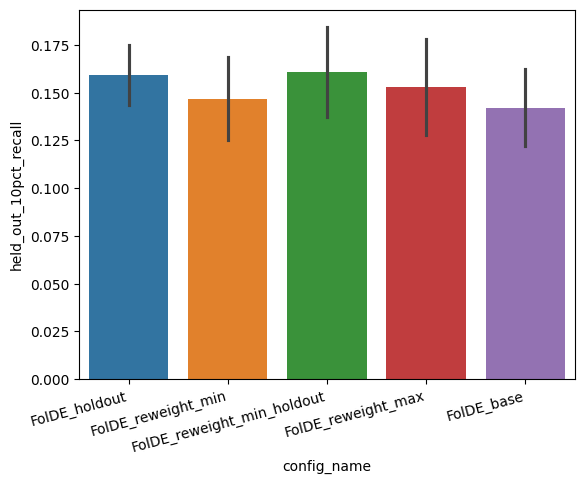

In [42]:
import seaborn as sns
sns.barplot(
    data=round_metrics_df[round_metrics_df['round_num'] == 2],
    x='config_name',
    y='held_out_10pct_recall',
    hue='config_name'
)
plt.xticks(rotation=15, ha='right')
plt.show()
